In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('PCOS_data.csv')
print(df.shape)

(541, 44)


In [3]:
print(df.dtypes)

Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)     object
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                 object
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)    

In [4]:
print(df.head())

   Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  Height(Cm)   \
0       1                 1           0          28         44.6        152.0   
1       2                 2           0          36         65.0        161.5   
2       3                 3           1          33         68.8        165.0   
3       4                 4           0          37         65.0        148.0   
4       5                 5           0          25         52.0        161.0   

    BMI  Blood Group  Pulse rate(bpm)   RR (breaths/min)  ...  Pimples(Y/N)  \
0  19.3           15                78                22  ...             0   
1  24.9           15                74                20  ...             0   
2  25.3           11                72                18  ...             1   
3  29.7           13                72                20  ...             0   
4  20.1           11                72                18  ...             0   

   Fast food (Y/N)  Reg.Exercise(Y/N) 

In [5]:
print(df.isnull().sum())

Sl. No                    0
Patient File No.          0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     1
Pregnant(Y/N)             0
No. of abortions          0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)     

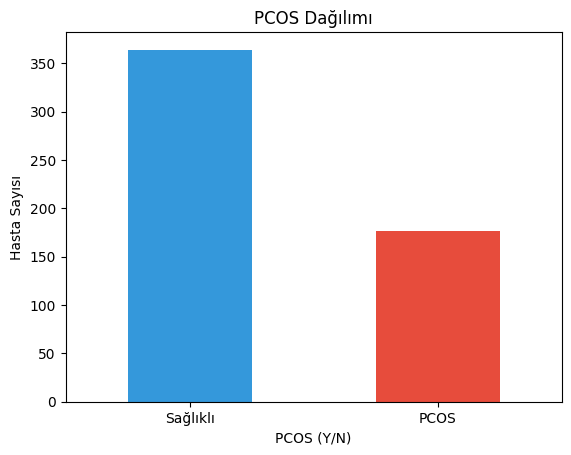

In [6]:
df['PCOS (Y/N)'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('PCOS Dağılımı')
plt.xticks([0, 1], ['Sağlıklı', 'PCOS'], rotation=0)
plt.ylabel('Hasta Sayısı')
plt.show()

In [7]:
karsilastirma = df.groupby('PCOS (Y/N)').mean(numeric_only=True).T
karsilastirma.columns = ['Sağlıklı', 'PCOS']
karsilastirma['Fark (%)'] = ((karsilastirma['PCOS'] - karsilastirma['Sağlıklı'])
                              / karsilastirma['Sağlıklı'] * 100).round(1)
print(karsilastirma.sort_values('Fark (%)', ascending=False))

                          Sağlıklı        PCOS  Fark (%)
LH(mIU/mL)                2.612676   14.402328     451.2
hair growth(Y/N)          0.129121    0.570621     341.9
Skin darkening (Y/N)      0.153846    0.621469     304.0
Vit D3 (ng/mL)           29.295005   92.322633     215.1
Weight gain(Y/N)          0.228022    0.683616     199.8
Follicle No. (R)          4.637363   10.762712     132.1
Follicle No. (L)          4.351648    9.785311     124.9
Fast food (Y/N)           0.382920    0.785311     105.1
Pimples(Y/N)              0.390110    0.694915      78.1
Hair loss(Y/N)            0.392857    0.576271      46.7
Cycle(R/I)                2.307692    3.079096      33.4
Reg.Exercise(Y/N)         0.228022    0.288136      26.4
Weight (Kg)              58.008791   62.985876       8.6
Sl. No                  264.357143  284.661017       7.7
Patient File No.        264.357143  284.661017       7.7
BMI                      23.743407   25.467797       7.3
Avg. F size (L) (mm)     14.687

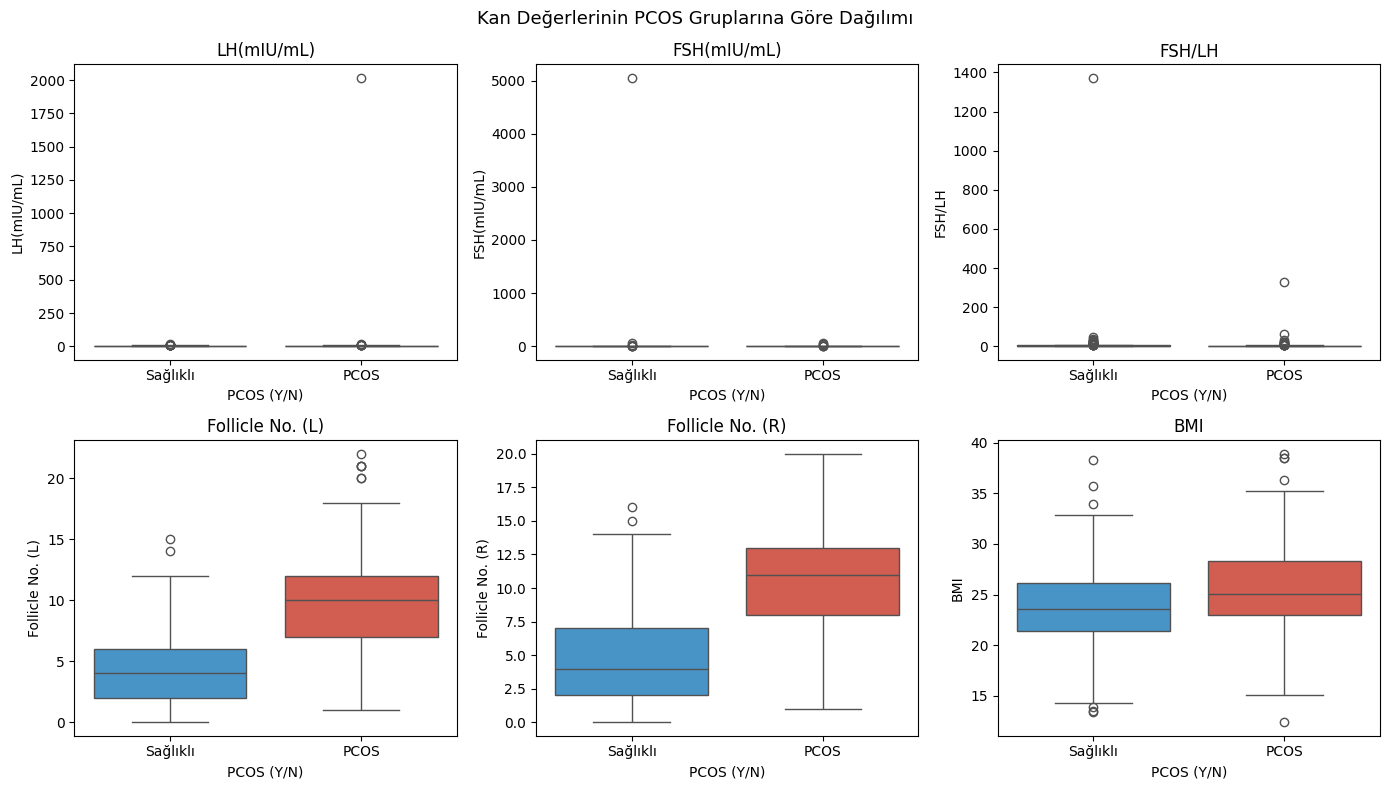

In [8]:
ozellikler = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'FSH/LH',
              'Follicle No. (L)', 'Follicle No. (R)', 'BMI']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(ozellikler):
    sns.boxplot(data=df, x='PCOS (Y/N)', y=col, ax=axes[i],
                hue='PCOS (Y/N)', palette=['#3498db', '#e74c3c'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sağlıklı', 'PCOS'])

plt.suptitle('Kan Değerlerinin PCOS Gruplarına Göre Dağılımı', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# aykırı değerleri temizle.
df_temiz = df.copy()

temizlenecek = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'FSH/LH']

for col in temizlenecek:
    Q1 = df_temiz[col].quantile(0.25)
    Q3 = df_temiz[col].quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    df_temiz = df_temiz[(df_temiz[col] >= alt) & (df_temiz[col] <= ust)]

print(f"Önce: {len(df)} hasta")
print(f"Sonra: {len(df_temiz)} hasta")
print(f"Çıkarılan: {len(df) - len(df_temiz)} hasta")

Önce: 541 hasta
Sonra: 460 hasta
Çıkarılan: 81 hasta


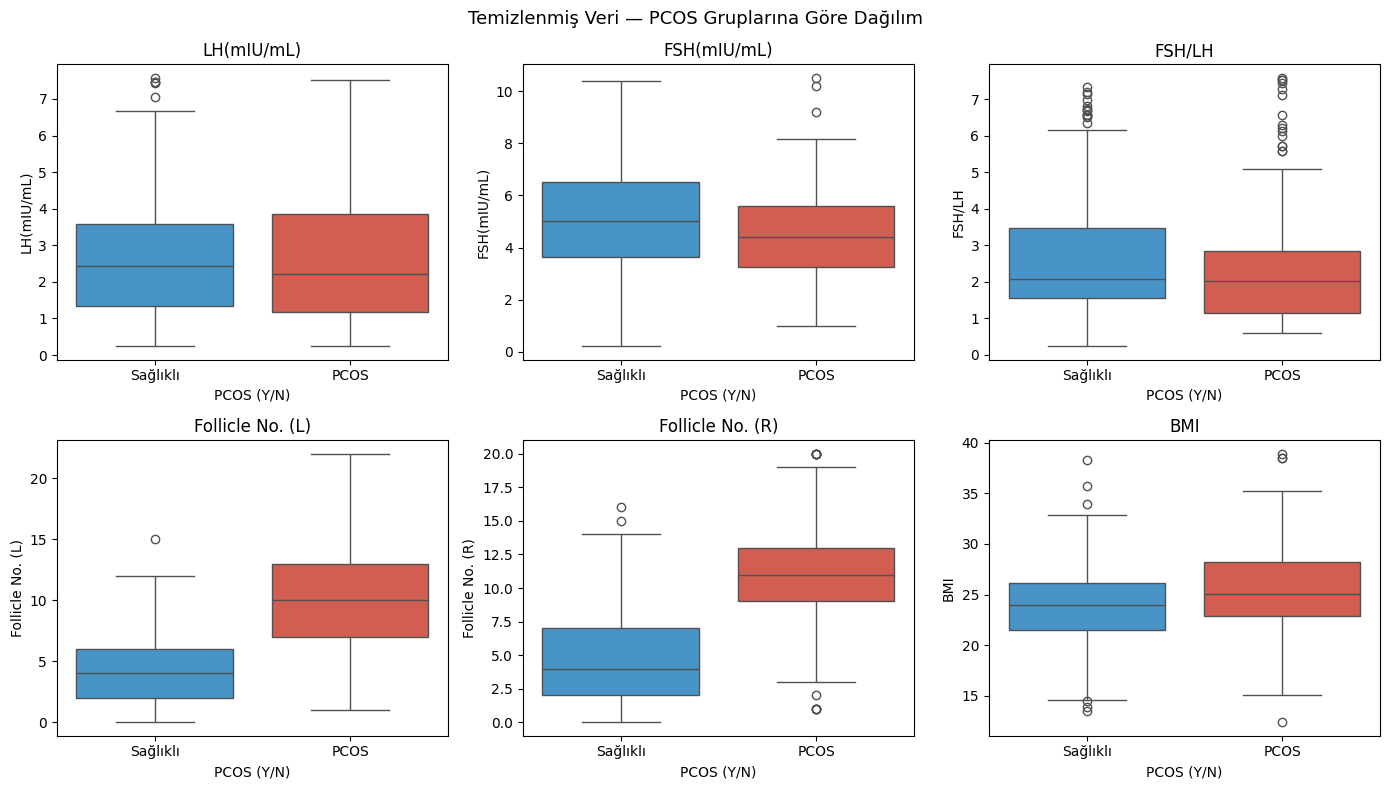

In [10]:
#temizlenmiş veriyle aynı grafiği tekrar çiz
ozellikler = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'FSH/LH',
              'Follicle No. (L)', 'Follicle No. (R)', 'BMI']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(ozellikler):
    sns.boxplot(data=df_temiz, x='PCOS (Y/N)', y=col, ax=axes[i],
                hue='PCOS (Y/N)', palette=['#3498db', '#e74c3c'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Sağlıklı', 'PCOS'])

plt.suptitle('Temizlenmiş Veri — PCOS Gruplarına Göre Dağılım', fontsize=13)
plt.tight_layout()
plt.show()

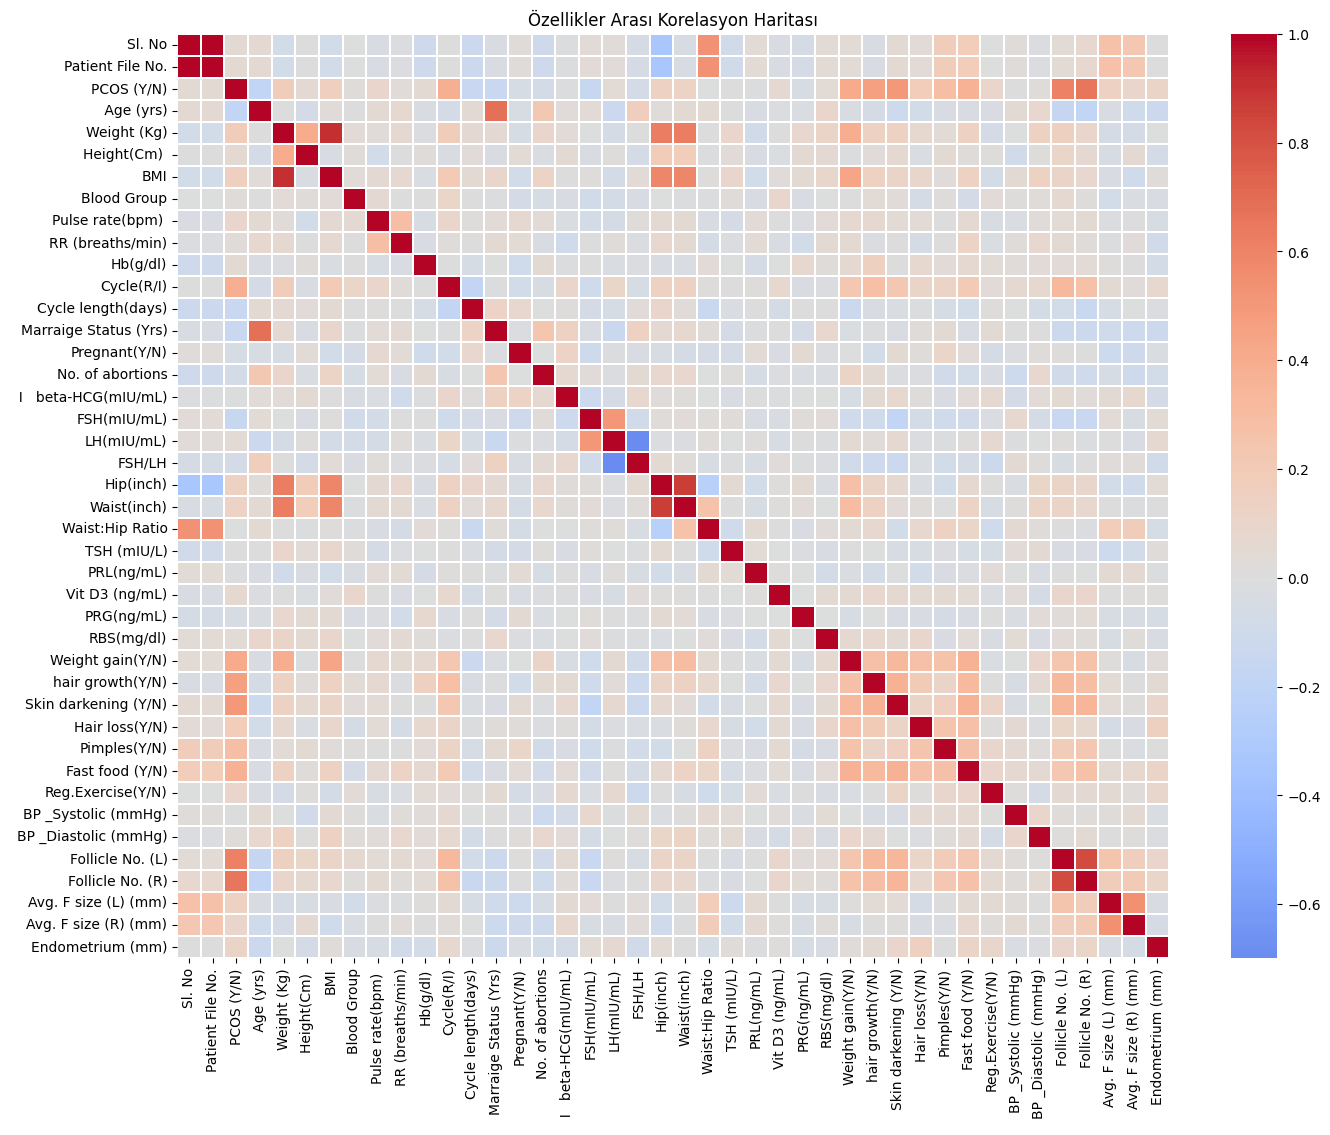

In [11]:
plt.figure(figsize=(16, 12))
sns.heatmap(df_temiz.select_dtypes(include='number').corr(), 
            cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Özellikler Arası Korelasyon Haritası')
plt.show()

In [12]:
# Birbirine çok bağlı ve gereksiz sütunları çıkar
df_model = df_temiz.drop(columns=[
    'Sl. No',              # sadece sıra numarası
    'Patient File No.',    # sadece sıra numarası
    'Hip(inch)',           # Waist ile çok bağlı
    'BMI',                 # Weight ile çok bağlı
    'Avg. F size (R) (mm)' # Avg. F size (L) ile çok bağlı
])

print(f"Önce: {df_temiz.shape[1]} sütun")
print(f"Sonra: {df_model.shape[1]} sütun")
print(f"Kalan sütunlar: {list(df_model.columns)}")

Önce: 44 sütun
Sonra: 39 sütun
Kalan sütunlar: ['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Endometrium (mm)']


In [13]:
# Eksik değerleri medyanla doldur
df_model = df_model.copy()

for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Kalan eksik değer: {df_model.isnull().sum().sum()}")

Kalan eksik değer: 0


In [14]:
# NORMALİZASYON

from sklearn.preprocessing import MinMaxScaler

# Hedef sütunu ayır
X = df_model.drop(columns=['PCOS (Y/N)'])
y = df_model['PCOS (Y/N)']

# Normalizasyon uygula
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(X_scaled.describe().round(2))

ValueError: could not convert string to float: '1.99.'

In [15]:
#veri içinde '1.99.' gibi sonda nokta olan bir değer var — bu sayıya çevrilemiyor.
#hatayı bul
for col in X.columns:
    try:
        X[col].astype(float)
    except:
        print(f"Sorunlu sütun: {col}")
        print(X[col].unique()[:10])

Sorunlu sütun: II    beta-HCG(mIU/mL)
['1.99' '494.08' '801.45' '100.51' '158.51' '1214.23' '91.55' '749.98'
 '218.65' '13']


In [16]:
#II beta-HCG sütunu string olarak okunmuş. 

# Sorunlu sütunu sayısala çevir
X['II    beta-HCG(mIU/mL)'] = pd.to_numeric(X['II    beta-HCG(mIU/mL)'], errors='coerce')
X['II    beta-HCG(mIU/mL)'] = X['II    beta-HCG(mIU/mL)'].fillna(X['II    beta-HCG(mIU/mL)'].median())

# Normalizasyon
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(X_scaled.describe().round(2))

        Age (yrs)  Weight (Kg)  Height(Cm)   Blood Group  Pulse rate(bpm)   \
count      460.00       460.00       460.00       460.00            460.00   
mean         0.41         0.37         0.45         0.39              0.87   
std          0.19         0.14         0.14         0.26              0.07   
min          0.00         0.00         0.00         0.00              0.00   
25%          0.25         0.29         0.35         0.29              0.86   
50%          0.39         0.38         0.44         0.43              0.86   
75%          0.54         0.44         0.53         0.57              0.88   
max          1.00         1.00         1.00         1.00              1.00   

       RR (breaths/min)  Hb(g/dl)  Cycle(R/I)  Cycle length(days)  \
count            460.00    460.00      460.00              460.00   
mean               0.27      0.38        0.18                0.30   
std                0.14      0.15        0.30                0.15   
min                0.

# Model Eğitimi XBoost

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (368, 38)
Test shape: (92, 38)


In [18]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=2,
    random_state=42
)

In [19]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9239130434782609


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94        62
           1       0.90      0.87      0.88        30

    accuracy                           0.92        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.92      0.92        92



### Confusion Matris

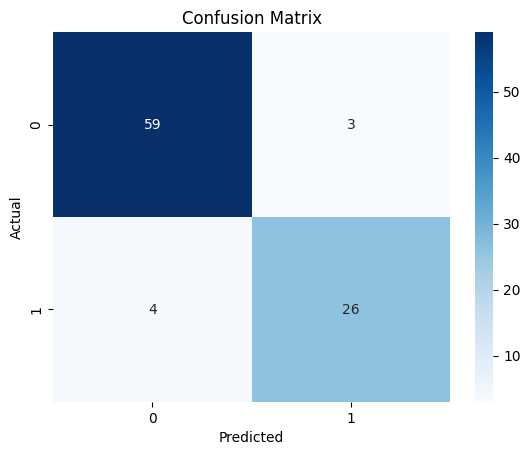

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

C:\Users\Kübra PARMAK\AppData\Local\Temp\ipykernel_25332\2822483817.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


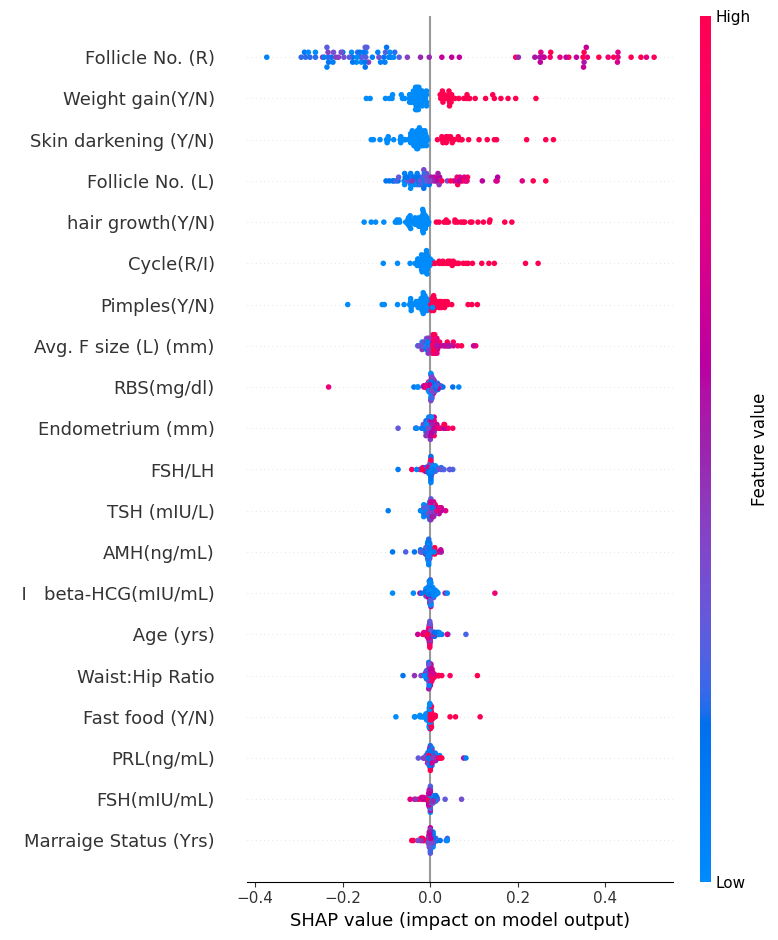

In [24]:
import shap

explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)